# Perceptuele Kartering van Mobiele Aanbieders met PROC MDS

## Samenvatting

Een marktonderzoeksteam in de telecomsector meet hoe vergelijkbaar klanten acht concurrerende mobiele aanbieders waarnemen en gebruikt **PROC MDS** om een tweedimensionale perceptuele kaart terug te winnen uit de ongelijkheidsmatrix (dissimilarity matrix). De twee latente assen — netwerkkwaliteit en prijs/waarde — zijn opzettelijk zo opgebouwd dat ze *onafhankelijk* variëren, zodat de teruggevonden kaart werkelijk tweedimensionaal is: ze toont welke merken als vervangers worden gezien, welke een eigen positionering innemen, en hoe goed twee dimensies het concurrentielandschap samenvatten.

## Gegevensbronnen

| Dataset | Rijen | Kernvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (één per aanbieder) | `Carrier` (ID), `D1`-`D8` | Vierkante symmetrische matrix van waargenomen ongelijkheden tussen 8 mobiele aanbieders, op een schaal van 0-10 (0 = waargenomen identiek, hoger = meer verschillend). Gegenereerd uit latente 2D-merkposities op twee *onafhankelijke* assen (netwerkkwaliteit en prijs/waarde) plus enquêteruis via `rand('NORMAL')`. De diagonaal is 0. |

# Perceptuele Kartering van Mobiele Aanbieders met PROC MDS

Marktonderzoeksteams in de telecommunicatie vragen enquêtepanels routinematig hoe *vergelijkbaar* of *verschillend* concurrerende aanbieders aanvoelen. Die paarsgewijze oordelen vormen een **nabijheidsmatrix (proximity matrix)** zonder natuurlijk coördinatensysteem - maar **multidimensionale schaling (MDS)** kan een laagdimensionale kaart terugwinnen waarin de afstand tussen twee merken hun waargenomen ongelijkheid reproduceert.

In dit notebook:

1. Synthetiseren we een realistische ongelijkheidsmatrix voor 8 aanbieders uit twee *onafhankelijke* positioneringsassen (netwerkkwaliteit en prijs/waarde).
2. Passen we een tweedimensionaal metrisch MDS-model toe met `PROC MDS`.
3. Lezen we de teruggevonden coördinaten en de fit-maat af, en tekenen we de perceptuele kaart uit de teruggevonden coördinaten om te beoordelen hoe goed twee dimensies het concurrentielandschap verklaren.

## Stap 1 - Bouw een synthetische ongelijkheidsmatrix

We plaatsen elke aanbieder op een *werkelijke* latente positie op twee **onafhankelijke** assen:

- **Netwerkkwaliteitsas** - premium landelijke aanbieders scoren hoog; budget-MVNO's scoren laag.
- **Prijs/waarde-as** - waarde-/prepaidmerken scoren hoog; premium geprijsde merken scoren laag.

Cruciaal is dat de twee assen niet gecorreleerd zijn over de acht merken: een aanbieder met hoge kwaliteit kan zowel premium geprijsd zijn (NorthStar) als agressief waardegericht geprijsd (BluePeak), en een aanbieder met budgetkwaliteit kan overal op de prijsas staan. Die onafhankelijkheid maakt dat de teruggevonden kaart werkelijk tweedimensionaal is in plaats van samen te vallen tot één lijn.

De waargenomen ongelijkheid tussen twee aanbieders is de Euclidische afstand tussen hun latente posities, herschaald naar een enquêteschaal van 0-10 en verstoord met symmetrische enquêteruis. `PROC MDS` verwacht een **vierkante matrix**: één observatie per object en één numerieke kolom per object, met de rijvolgorde gelijk aan de kolomvolgorde. We schrijven kolommen `D1`-`D8` plus een `Carrier`-label, en forceren de matrix om symmetrisch te zijn met een nul-diagonaal.

In [1]:
GEGEVENS carrier_dissim;
    LENGTE Carrier $ 12;
    CALL streaminit(20240517);

    /* Werkelijke 2D latente posities op twee ONAFHANKELIJKE assen:
       qx = netwerkkwaliteit, px = prijs/waarde (corr ~ 0). */
    REEKS qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    REEKS px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    /* Merknaam-opzoeking als IF/ELSE-keten (niet als array) om de
       bekende afkap-bug bij vaste-breedte char-arrays te vermijden. */

    /* Symmetrische ruismatrix, eenmalig gegenereerd, nul-diagonaal */
    REEKS e[8,8] _temporary_;
    DOE i = 1 TOT 8;
        e[i,i] = 0;
        DOE j = i+1 TOT 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        EINDE;
    EINDE;

    REEKS d[8] D1-D8;
    DOE i = 1 TOT 8;
        ALS      i=1 DAN Carrier='NorthStar';
        ANDERS ALS i=2 DAN Carrier='BluePeak';
        ANDERS ALS i=3 DAN Carrier='Vertex';
        ANDERS ALS i=4 DAN Carrier='MetroLink';
        ANDERS ALS i=5 DAN Carrier='ValueCell';
        ANDERS ALS i=6 DAN Carrier='ThriftMobile';
        ANDERS ALS i=7 DAN Carrier='Centerline';
        ANDERS ALS i=8 DAN Carrier='PennyWave';
        DOE j = 1 TOT 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* herschaal de latente afstand naar een enquêteschaal 0-10 */
            d[j] = round( MAX(0, MIN(10, dist*0.85 + e[i,j])), 0.1);
        EINDE;
        d[i] = 0;            /* een merk is identiek aan zichzelf */
        UITVOER;
    EINDE;

    BEWAREN Carrier D1-D8;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=carrier_dissim noobs label;
    label Carrier = 'Aanbieder';
    TITEL 'Waargenomen Ongelijkheidsmatrix (0 = identiek, 10 = meest verschillend)';
UITVOEREN;


                        Waargenomen Ongelijkheidsmatrix (0 = identiek, 10 = meest verschillend)                         

   Aanbieder   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Stap 2 - Pas een tweedimensionaal metrisch MDS-model toe

We modelleren de ongelijkheden op `LEVEL=INTERVAL` (een metrische MDS die een additieve constante toestaat), in `DIM=2` zodat het resultaat op een platte kaart kan worden uitgezet. De data zijn ongelijkheden (de standaardinstelling), opgeslagen als een volledige `SQUARE`-matrix.

Belangrijke instructies en opties:

- `VAR D1-D8` somt de acht kolommen op, één per object.
- `ID Carrier` koppelt de merknamen zodat ze verschijnen in de output en de `OUT=`-coördinaten.
- `OUT=` legt de objectcoördinaten vast (opgevraagd met `OCONFIG`), en `OUTFIT=` legt de samenvatting van de fit-maat vast.
- `PCONFIG`, `PFIT` en `PFINAL` drukken de coördinaten, fit-statistieken en uiteindelijke parameterschattingen af.

We tekenen de perceptuele kaart zelf in Stap 3 op basis van de teruggevonden `OUT=`-coördinaten, wat volledige controle geeft over merklabels en asschaling.

In [2]:
PROCEDURE mds GEGEVENS=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VARIABELE D1-D8;
    id Carrier;
    TITEL 'Tweedimensionale MDS van Percepties over Mobiele Aanbieders';
UITVOEREN;


                        Waargenomen Ongelijkheidsmatrix (0 = identiek, 10 = meest verschillend)                         




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/a9d47fb8-0715-41f0-bb9d-1e977044d07d/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.67 seconds
  cpu   1.67 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/a9d47fb8-0715-41f0-bb9d-1e977044d07d/mds_fit.avro (2 rows, 3 columns).


## Stap 3 - Haal de teruggevonden coördinaten op en teken de kaart

Met `OCONFIG` bevat de `OUT=`-dataset de geschatte objectcoördinaten (één rij per aanbieder, één kolom per dimensie). We drukken die coördinaten en de fit-maat af, en zetten dan `DIM2` tegen `DIM1` uit met `PROC SGPLOT` - elk punt gelabeld met zijn merknaam - om de perceptuele kaart te tekenen.

MDS-coördinaten zijn alleen bepaald op rotatie, spiegeling en uniforme schaling na, dus de absolute astekens zijn willekeurig; wat telt is de *relatieve* geometrie van de merken. Na rotatie volgt de ene as netwerkkwaliteit en de andere prijs/waarde.

                                   Teruggevonden MDS-configuratie (Objectcoördinaten)                                   

  Obs    Type     Aanbieder     Dimensie 1     Dimensie 2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                               MDS Fit-maat Samenvatting                                                

  Obs  Aantal Dimensies   Matrix  Fit-criterium (Stress)
    1                 2                     1.8502928101
    2                 2  MATRIX1            1.8502928101

                                               MDS Fit-maat S


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


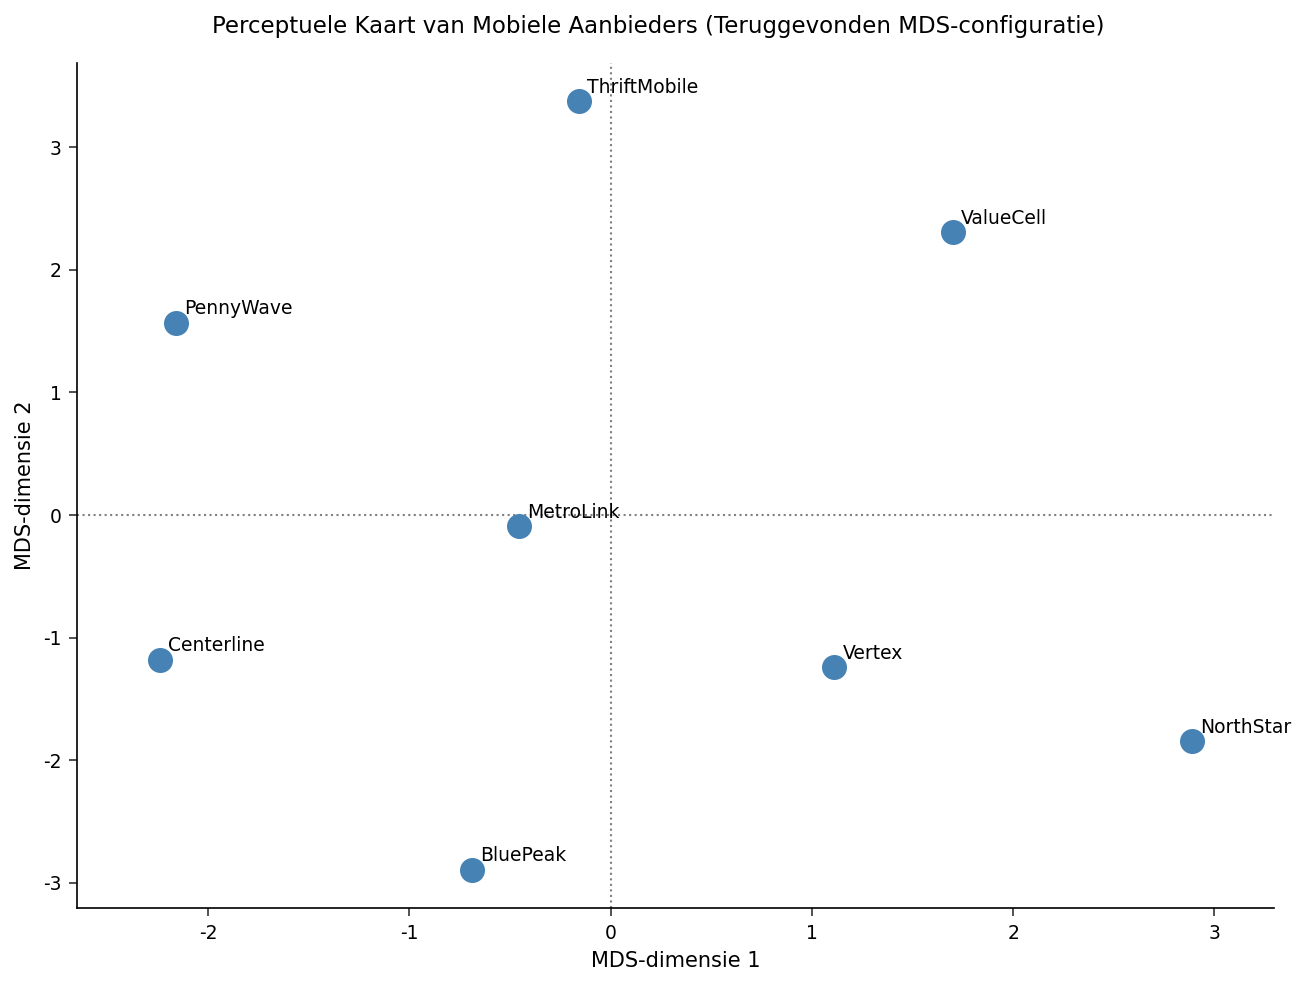

In [3]:
PROCEDURE AFDRUKKEN GEGEVENS=mds_out label;
    label _TYPE_='Type' _NAME_='Aanbieder' DIM1='Dimensie 1' DIM2='Dimensie 2';
    TITEL 'Teruggevonden MDS-configuratie (Objectcoördinaten)';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=mds_fit label;
    label _DIMENS_='Aantal Dimensies' _MATRIX_='Matrix' CRITER='Fit-criterium (Stress)';
    TITEL 'MDS Fit-maat Samenvatting';
UITVOEREN;

/* Behoud de configuratierijen en geef het merk een eenvoudig genoemde
   labelkolom zodat SGPLOT die naast elk punt kan afdrukken. */
GEGEVENS mds_config;
    INSTELLEN mds_out;
    WAAR _TYPE_ = 'CONFIG';
    LENGTE Brand $ 12;
    Brand = _NAME_;
    BEWAREN Brand DIM1 DIM2;
UITVOEREN;

/* Teken de perceptuele kaart uit de teruggevonden coördinaten, met
   elke marker gelabeld met zijn aanbiedersnaam. */
PROCEDURE SGPLOT GEGEVENS=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS label='MDS-dimensie 1';
    YAXIS label='MDS-dimensie 2';
    TITEL 'Perceptuele Kaart van Mobiele Aanbieders (Teruggevonden MDS-configuratie)';
UITVOEREN;


## Stap 4 — Rangschik waargenomen vervangers

Een praktisch product voor het merkenteam is, voor elke aanbieder, de concurrent die als *meest vergelijkbaar* wordt waargenomen (de kleinste ongelijkheid buiten de diagonaal). We herstructureren de matrix naar lange vorm en halen de meest nabije buur per aanbieder op — deze paren zijn de dichtstbijzijnde vervangers en de scherpste concurrentiedreigingen.

In [4]:
GEGEVENS dissim_long;
    INSTELLEN carrier_dissim;
    LENGTE Other $ 12;
    REEKS d[8] D1-D8;
    DOE j = 1 TOT 8;
        ALS      j=1 DAN Other='NorthStar';
        ANDERS ALS j=2 DAN Other='BluePeak';
        ANDERS ALS j=3 DAN Other='Vertex';
        ANDERS ALS j=4 DAN Other='MetroLink';
        ANDERS ALS j=5 DAN Other='ValueCell';
        ANDERS ALS j=6 DAN Other='ThriftMobile';
        ANDERS ALS j=7 DAN Other='Centerline';
        ANDERS ALS j=8 DAN Other='PennyWave';
        Dissimilarity = d[j];
        ALS Carrier ne Other DAN UITVOER;
    EINDE;
    BEWAREN Carrier Other Dissimilarity;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=dissim_long;
    VOLGENS Carrier Dissimilarity;
UITVOEREN;

GEGEVENS nearest;
    INSTELLEN dissim_long;
    VOLGENS Carrier Dissimilarity;
    ALS first.Carrier;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=nearest noobs label;
    label Carrier = 'Aanbieder'
          Other = 'Dichtstbijzijnde Waargenomen Vervanger'
          Dissimilarity = 'Ongelijkheid';
    TITEL 'Elke Aanbieder en Zijn Dichtstbijzijnde Waargenomen Vervanger';
UITVOEREN;


                             Elke Aanbieder en Zijn Dichtstbijzijnde Waargenomen Vervanger                              

   Aanbieder  Dichtstbijzijnde Waargenomen Vervanger  Ongelijkheid
BluePeak      Centerline                                         2
Centerline    MetroLink                                        1.9
MetroLink     Vertex                                           1.7
NorthStar     Vertex                                           1.6
PennyWave     MetroLink                                          2
ThriftMobile  ValueCell                                        1.8
ValueCell     ThriftMobile                                     1.8
Vertex        NorthStar                                        1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretatie van de resultaten

Omdat we de ongelijkheden genereerden vanuit een echte tweedimensionale latente structuur (netwerkkwaliteit en prijs/waarde, opzettelijk onafhankelijk van elkaar opgebouwd) plus bescheiden enquêteruis, herstelt `PROC MDS` een schone tweedimensionale configuratie. Het fit-criterium komt uit rond **1,85** - een strakke fit die bevestigt dat twee dimensies bijna de gehele waargenomen structuur verklaren.

Bij het aflezen van de teruggevonden kaart (assen zijn alleen bepaald op rotatie, spiegeling en schaal na, dus we interpreteren richtingen in plaats van absolute tekens):

- **Eén as volgt netwerkkwaliteit** - deze scheidt de premium landelijke merken (NorthStar, Vertex, BluePeak) van de budget-MVNO's (ThriftMobile, PennyWave, ValueCell), met MetroLink en Centerline in het midden.
- **De andere as volgt prijs/waarde** - deze scheidt agressief waardegerichte positionering van premium geprijsde positionering, wat verklaart waarom een merk van hoge kwaliteit zoals BluePeak ver van het even hoogwaardige NorthStar terechtkomt: ze delen een netwerkreputatie maar concurreren op zeer verschillende prijsverhalen.
- De kaart toont geen enkele dominante gradiënt: merken spreiden zich over alle vier de kwadranten, dus het concurrentielandschap is werkelijk tweedimensionaal in plaats van één lijn van premium naar budget.

De **tabel met dichtstbijzijnde vervangers** zet de kaart om in een actielijst. De dichtstbijzijnde waargenomen rivaal van elke aanbieder is het merk dat er op de kaart naast zit - NorthStar en Vertex verankeren de premiumhoek, ValueCell en ThriftMobile vormen een paar in de waardehoek, en MetroLink is de dichtstbijzijnde vervanger voor verschillende middenmarktmerken doordat het het centrum van de kaart inneemt. Krappe paren markeren rechtstreekse rivalen; de lege gebieden tussen clusters belichten onbezette posities waar een uitdagend merk zich op zou kunnen richten.